# Physical-Mode Activation — Demo Notebook

A walkthrough of the Sub-task 1 pipeline end-to-end. Run each cell in order
to see:

1. How the factorial stimuli are rendered (axes A, B, C)
2. How Qwen2.5-VL-7B is loaded and queried
3. How PMR / GAR scoring works on the raw responses
4. The full pilot results (480 inferences, already computed) with plots

Expected runtime: **< 2 min** if the pilot output + model weights are already
cached (as they are right after running `scripts/02_run_inference.py`).
Otherwise a one-time ~15 GB model download adds a few minutes.

References:
- Architecture: `docs/00_architecture.md`
- Scoring rubric: `docs/02_scoring_rubric.md`
- Run log: `docs/03_run_log.md`
- Research plan: `research_plan.md` (Korean)


## 0. Setup

Launch Jupyter from inside the project venv so all imports resolve:

```bash
uv run jupyter notebook notebooks/demo.ipynb
# or
uv run jupyter lab
```


In [1]:
import sys
import time
from pathlib import Path

# Make `physical_mode` importable whether we launched from the project root
# or from inside notebooks/.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import torch

print(f"Python     : {sys.version.split()[0]}")
print(f"PyTorch    : {torch.__version__}")
print(f"CUDA avail : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU        : {torch.cuda.get_device_name(0)}")
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM       : {vram:.1f} GB")
print(f"Project root: {PROJECT_ROOT}")


Python     : 3.11.11
PyTorch    : 2.11.0+cu130
CUDA avail : True
GPU        : NVIDIA H200
VRAM       : 150.1 GB
Project root: /mnt/ddn/prod-runs/thyun.park/src/physical_mode_activation


---
## Part 1 — Stimulus generation

The factorial spec defines four axes: **object abstraction** (A), **background**
(B), **context cue** (C), and **event template**. A fifth axis (**label**) is
applied at prompt-time, not in the image. The research plan §2.2 calls for
108 factorial cells; for the pilot we use a reduced 48-cell subset.


In [2]:
from physical_mode.config import EvalConfig, FactorialSpec, StimulusRow

spec = FactorialSpec(
    object_levels=("line", "filled", "shaded", "textured"),
    bg_levels=("blank", "ground"),
    cue_levels=("none", "wind", "arrow_shadow"),
    event_templates=("fall", "horizontal"),
    seeds_per_cell=5,
)
print(f"Factorial cells         : {len(spec.object_levels) * len(spec.bg_levels) * len(spec.cue_levels) * len(spec.event_templates)}")
print(f"Total stimuli (with seed): {spec.total()}")
print()
print("First 6 StimulusRows:")
for i, row in enumerate(spec.iter()):
    if i >= 6:
        break
    print(" ", row)


Factorial cells         : 48
Total stimuli (with seed): 240

First 6 StimulusRows:
  StimulusRow(sample_id='line_blank_none_fall_000', event_template='fall', object_level='line', bg_level='blank', cue_level='none', seed=1000)
  StimulusRow(sample_id='line_blank_none_fall_001', event_template='fall', object_level='line', bg_level='blank', cue_level='none', seed=1001)
  StimulusRow(sample_id='line_blank_none_fall_002', event_template='fall', object_level='line', bg_level='blank', cue_level='none', seed=1002)
  StimulusRow(sample_id='line_blank_none_fall_003', event_template='fall', object_level='line', bg_level='blank', cue_level='none', seed=1003)
  StimulusRow(sample_id='line_blank_none_fall_004', event_template='fall', object_level='line', bg_level='blank', cue_level='none', seed=1004)
  StimulusRow(sample_id='line_blank_none_horizontal_000', event_template='horizontal', object_level='line', bg_level='blank', cue_level='none', seed=1005)


Size: (512, 512)


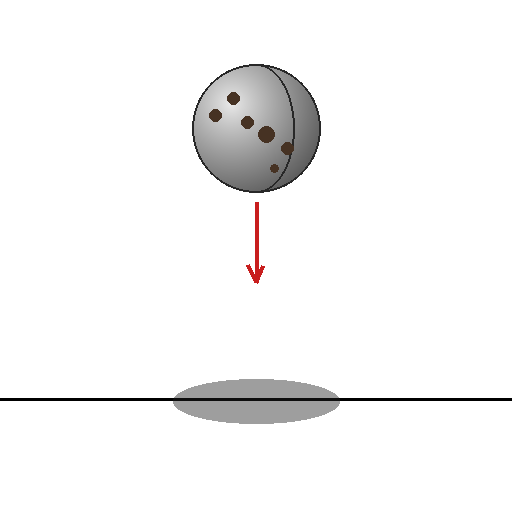

In [3]:
from physical_mode.stimuli.scenes import render_scene
from IPython.display import display

row = StimulusRow(
    sample_id="demo",
    event_template="fall",
    object_level="textured",
    bg_level="ground",
    cue_level="arrow_shadow",
    seed=42,
)
img = render_scene(row)
print(f"Size: {img.size}")
display(img)


### Axis A — abstraction levels (line → textured)

The research-plan hypothesis is that PMR rises monotonically across this axis.
From left to right, more "physical-object-ness" cues are layered in:
plain outline → uniform fill → 3D shading (Ramachandran light-from-above)
→ texture + seam.

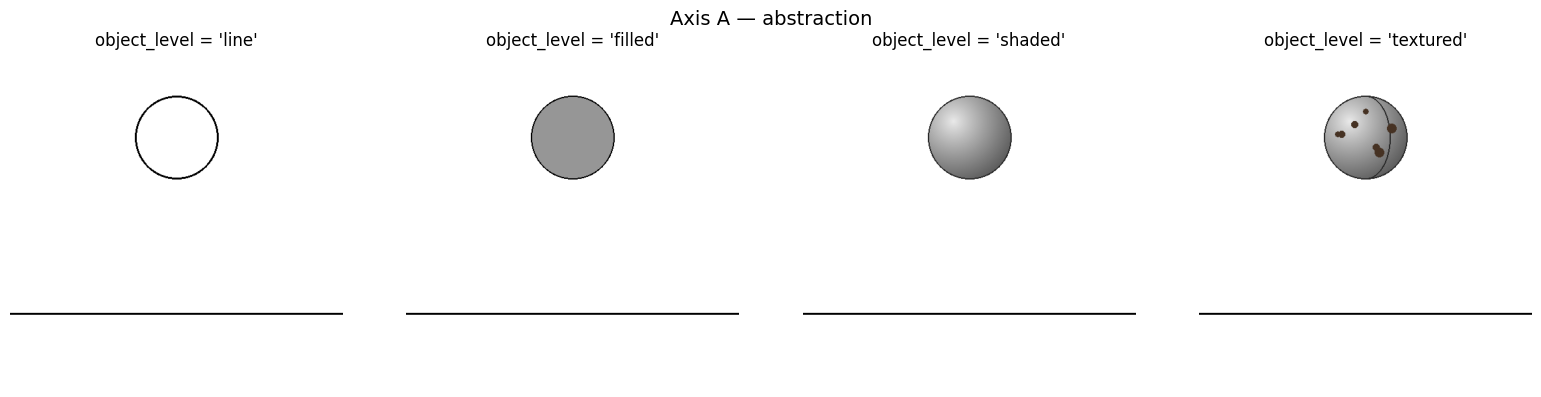

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, level in zip(axes, ("line", "filled", "shaded", "textured")):
    r = StimulusRow("x", "fall", level, "ground", "none", 100)
    ax.imshow(render_scene(r))
    ax.set_title(f"object_level = '{level}'")
    ax.axis("off")
plt.suptitle("Axis A — abstraction", fontsize=14)
plt.tight_layout()
plt.show()


### Axis B — background (blank → ground → scene)

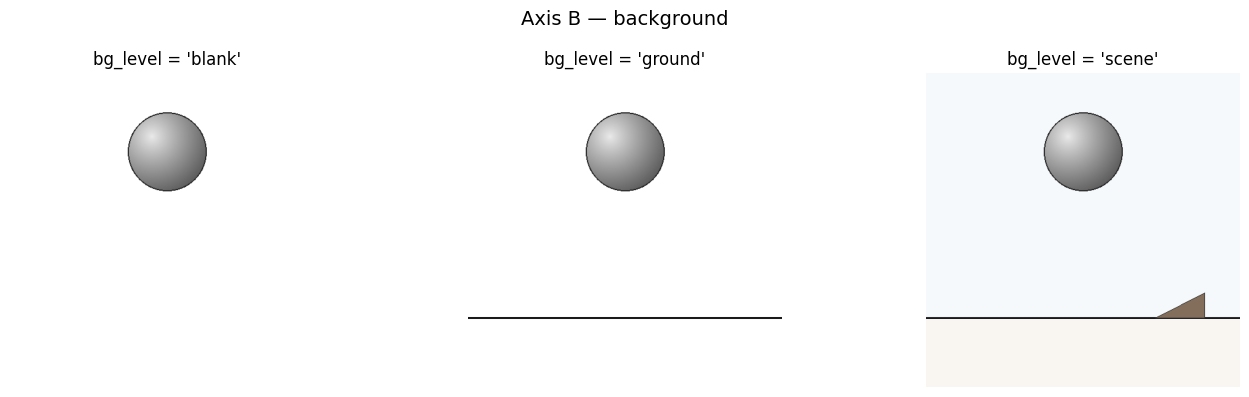

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, bg in zip(axes, ("blank", "ground", "scene")):
    r = StimulusRow("x", "fall", "shaded", bg, "none", 300)
    ax.imshow(render_scene(r))
    ax.set_title(f"bg_level = '{bg}'")
    ax.axis("off")
plt.suptitle("Axis B — background", fontsize=14)
plt.tight_layout()
plt.show()


### Axis C — context cue (none → wind → arrow+shadow)

- `wind`: grey arcs trailing the object (suggest airflow).
- `arrow_shadow`: elliptical cast shadow on the ground + a red trajectory arrow.


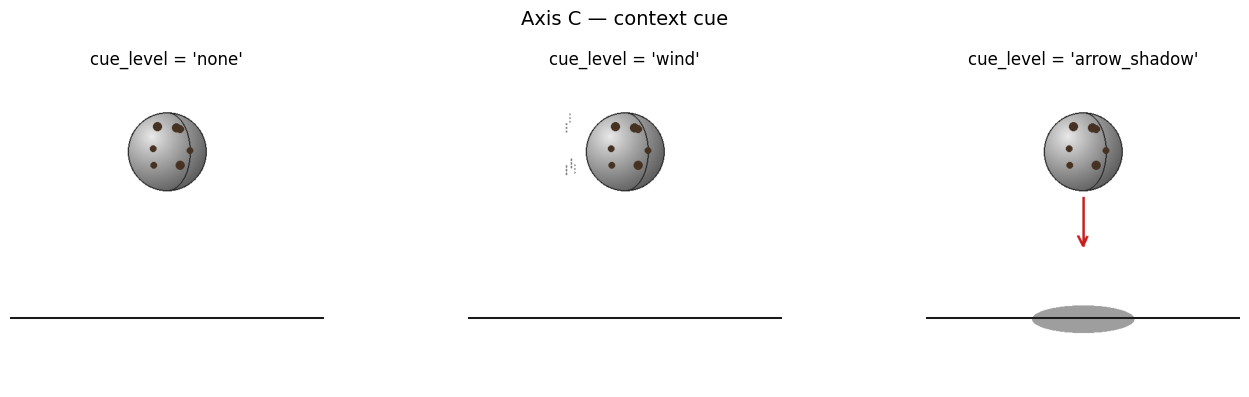

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, cue in zip(axes, ("none", "wind", "arrow_shadow")):
    r = StimulusRow("x", "fall", "textured", "ground", cue, 200)
    ax.imshow(render_scene(r))
    ax.set_title(f"cue_level = '{cue}'")
    ax.axis("off")
plt.suptitle("Axis C — context cue", fontsize=14)
plt.tight_layout()
plt.show()


---
## Part 2 — Load Qwen2.5-VL-7B and run a few inferences

Weights are already cached locally (from the pilot run). Model load is ~8 s
on the H200; the first run with a new weight cache would include a ~15 GB
download.

In [7]:
from physical_mode.models.vlm_runner import PhysModeVLM, InferenceArgs

t0 = time.time()
vlm = PhysModeVLM(
    model_id="Qwen/Qwen2.5-VL-7B-Instruct",
    torch_dtype="bfloat16",
    device="cuda",
)
print(f"Loaded in {time.time() - t0:.1f}s")
print(f"Model id       : {vlm.model_id}")
print(f"Image token id : {vlm.image_token_id}")

# A quick VRAM check.
if torch.cuda.is_available():
    used = torch.cuda.memory_allocated() / 1e9
    print(f"VRAM allocated : {used:.1f} GB")


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Loaded in 20.4s
Model id       : Qwen/Qwen2.5-VL-7B-Instruct
Image token id : 151655
VRAM allocated : 16.6 GB


### Demo inferences

Three stimuli that span the predicted PMR spectrum:

- **line + blank + no cue** → most abstract, expect PMR = 0.
- **shaded + ground + no cue** → 3D cue + support plane, expect PMR = 1.
- **textured + ground + arrow+shadow** → maximal cue, expect PMR = 1 + directional.

For each stimulus we run *both* the open-ended and forced-choice prompts.

Stimulus: line/blank/none/fall


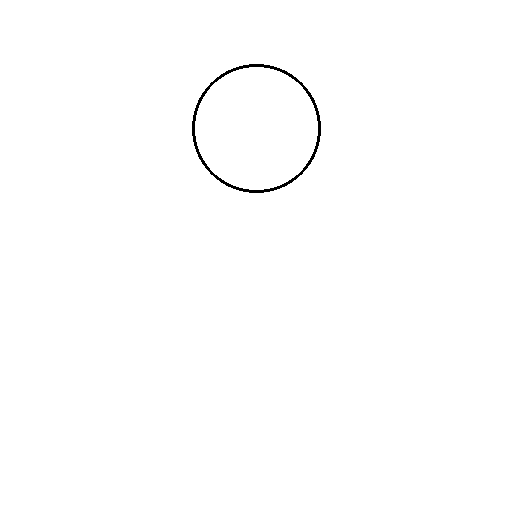

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  [         open]  The ball will remain stationary unless acted upon by an external force.


  [forced_choice]  D  The image is an abstract representation of a circle and does not depict a physical object like a ball that can fall, move, or stay still. Therefore, it cannot be described in terms of physical motion.

Stimulus: shaded/ground/none/fall


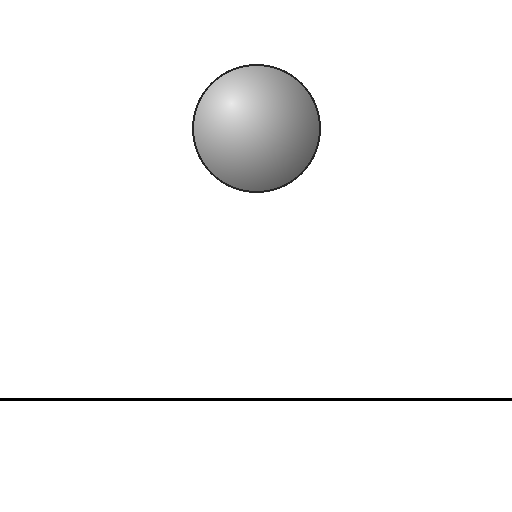

  [         open]  The ball will fall downward due to gravity.


  [forced_choice]  A) It falls down.  Justification: The ball appears to be in free fall above a horizontal line, which typically represents the ground. In the absence of any forces acting on it other than gravity, the ball would naturally

Stimulus: textured/ground/arrow_shadow/fall


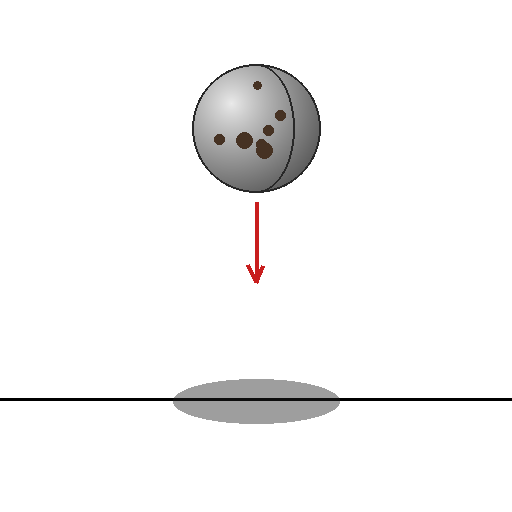

  [         open]  The ball will collide with the surface below it.


  [forced_choice]  A; The red arrow indicates a downward direction, suggesting that the ball will fall due to gravity.



In [8]:
from physical_mode.inference.prompts import render as render_prompt

demo_rows = [
    StimulusRow("line/blank/none",          "fall", "line",     "blank",  "none",         100),
    StimulusRow("shaded/ground/none",       "fall", "shaded",   "ground", "none",         101),
    StimulusRow("textured/ground/arrow",    "fall", "textured", "ground", "arrow_shadow", 102),
]
args = InferenceArgs(max_new_tokens=80, temperature=0.0)

demo_records = []
for row in demo_rows:
    img = render_scene(row)
    print("=" * 80)
    print(f"Stimulus: {row.object_level}/{row.bg_level}/{row.cue_level}/{row.event_template}")
    display(img)
    for variant in ("open", "forced_choice"):
        rp = render_prompt(variant, "ball")
        out = vlm.generate(
            image=img, prompt=rp.user, args=args,
            system_prompt=rp.system, choice_tokens=rp.choice_letters,
        )
        text = out["raw_text"].replace("\n", " ")[:220]
        print(f"  [{variant:>13}]  {text}")
        demo_records.append({
            "sample_id": row.sample_id,
            "object_level": row.object_level,
            "bg_level": row.bg_level,
            "cue_level": row.cue_level,
            "event_template": row.event_template,
            "label": "ball",
            "prompt_variant": variant,
            "raw_text": out["raw_text"],
        })
    print()


---
## Part 3 — PMR / GAR scoring on the demo responses

The scorer (defined in `src/physical_mode/metrics/pmr.py`) applies a simple
lexicon of physics-verb stems and abstract-rejection phrases. Reliable at
scale, easy to audit. See `docs/02_scoring_rubric.md` for the full rule.

In [9]:
import pandas as pd
from physical_mode.metrics.pmr import score_rows

demo_df = score_rows(pd.DataFrame(demo_records))
demo_df[[
    "object_level", "bg_level", "cue_level", "prompt_variant",
    "raw_text", "pmr", "gar", "hold_still", "abstract_reject",
]]


,object_level,bg_level,cue_level,prompt_variant,raw_text,pmr,gar,hold_still,abstract_reject
0,line,blank,none,open,The ball will remain stationary unless acted u...,0,NaN,1,0
1,line,blank,none,forced_choice,D\n\nThe image is an abstract representation o...,0,NaN,1,1
2,shaded,ground,none,open,The ball will fall downward due to gravity.,1,1.0,0,0
3,shaded,ground,none,forced_choice,A) It falls down.\n\nJustification: The ball a...,1,1.0,0,0
4,textured,ground,arrow_shadow,open,The ball will collide with the surface below it.,1,1.0,0,0
5,textured,ground,arrow_shadow,forced_choice,A; The red arrow indicates a downward directio...,1,1.0,0,0


---
## Part 4 — Full pilot results (480 predictions)

The heavy lifting was already done by `scripts/02_run_inference.py` and
scored by `scripts/03_score_and_summarize.py`. This section loads those
outputs and reproduces the key figures in `docs/03_run_log.md`.

In [10]:
# Auto-discover the latest pilot output directory.
outputs_root = PROJECT_ROOT / "outputs"
pilot_dirs = sorted(outputs_root.glob("pilot_*"))
# Filter to ones with actual predictions (skip partial smokes).
pilot_dirs = [p for p in pilot_dirs if (p / "predictions.jsonl").exists()
              and sum(1 for _ in open(p / "predictions.jsonl")) >= 400]
if not pilot_dirs:
    raise FileNotFoundError(
        "No pilot output with >=400 predictions found.\n"
        "Run: uv run python scripts/02_run_inference.py --config configs/pilot.py"
    )
pilot_dir = pilot_dirs[-1]
print(f"Using: {pilot_dir.relative_to(PROJECT_ROOT)}")

pilot_df = pd.read_json(pilot_dir / "predictions.jsonl", orient="records", lines=True)
pilot_df = score_rows(pilot_df)
print(f"Loaded {len(pilot_df)} predictions")
pilot_df[["object_level", "bg_level", "cue_level", "prompt_variant", "pmr", "gar"]].head()


Using: outputs/pilot_20260424-072418_2c16efb6
Loaded 480 predictions


,object_level,bg_level,cue_level,prompt_variant,pmr,gar
0,line,blank,none,open,0,NaN
1,line,blank,none,forced_choice,0,NaN
2,line,blank,none,open,0,NaN
3,line,blank,none,forced_choice,0,NaN
4,line,blank,none,open,0,NaN


In [11]:
from physical_mode.metrics.pmr import summarize

sums = summarize(pilot_df)
print("=== Overall ===")
display(sums["overall"])


=== Overall ===


,n,pmr,hold_still,abstract_reject,gar
0,480,0.670833,0.304167,0.225,0.783333


### PMR by object_level (axis A — abstraction)

H1: monotone S-curve from `line` → `textured`. Observed: endpoints
behave as predicted, middle two tied (plausibly noise at n=120).

,object_level,n,pmr,hold_still,abstract_reject,gar
0,line,120,0.575000,0.333333,0.325000,0.666667
1,filled,120,0.658333,0.333333,0.225000,0.866667
2,shaded,120,0.641667,0.408333,0.183333,1.000000
3,textured,120,0.808333,0.141667,0.166667,0.600000


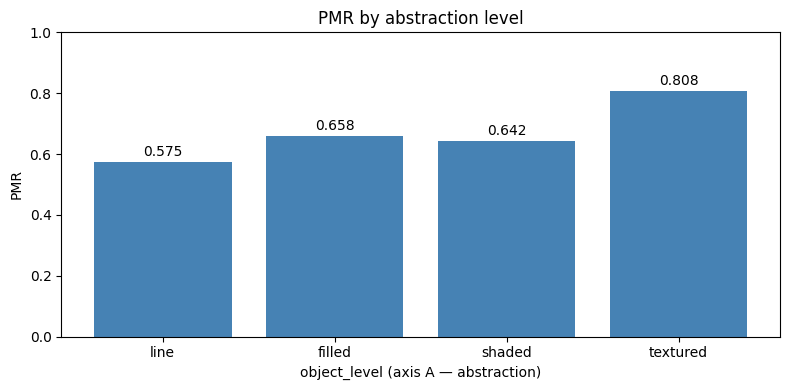

In [12]:
obj_df = sums["by_object_level"]
obj_order = ["line", "filled", "shaded", "textured"]
obj_df = obj_df.set_index("object_level").loc[obj_order].reset_index()
display(obj_df)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(obj_df["object_level"], obj_df["pmr"], color="steelblue")
ax.set_ylim(0, 1)
ax.set_ylabel("PMR")
ax.set_xlabel("object_level (axis A — abstraction)")
ax.set_title("PMR by abstraction level")
for b, v in zip(bars, obj_df["pmr"]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()


### PMR by bg_level (axis B — background)

The biggest single-factor effect in the pilot: a ground line alone adds
+36 pp to PMR. Supports the Kersten/Mamassian + Gibson prediction that
a support plane anchors physical-object interpretation.

,bg_level,n,pmr,hold_still,abstract_reject,gar
0,blank,240,0.487500,0.466667,0.3125,NaN
1,ground,240,0.854167,0.141667,0.1375,0.783333


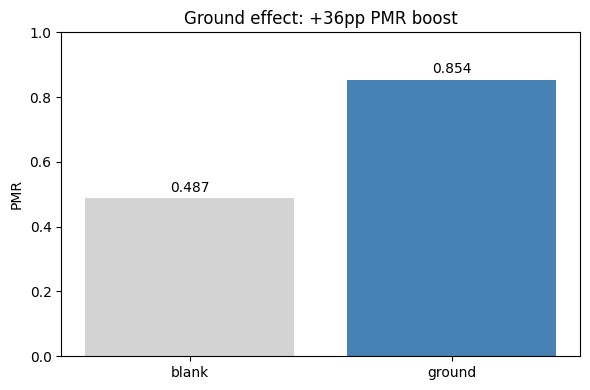

In [13]:
bg_df = sums["by_bg_level"]
display(bg_df)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(bg_df["bg_level"], bg_df["pmr"], color=["lightgray", "steelblue"])
ax.set_ylim(0, 1)
ax.set_ylabel("PMR")
ax.set_title("Ground effect: +36pp PMR boost")
for b, v in zip(bars, bg_df["pmr"]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()


### PMR by cue_level (axis C — context cue)

- `arrow_shadow` saturates PMR at 1.00 → too strong a cue; split it into
  shadow-only and arrow-only in MVP-full.
- `wind` ≈ `none` → the programmatic wind streaks are not being read as
  airflow by Qwen2.5-VL. Rework the visual or replace with motion-blur.

,cue_level,n,pmr,hold_still,abstract_reject,gar
0,none,160,0.5000,0.51875,0.300,0.775
1,wind,160,0.5125,0.38125,0.375,0.575
2,arrow_shadow,160,1.0000,0.01250,0.000,1.000


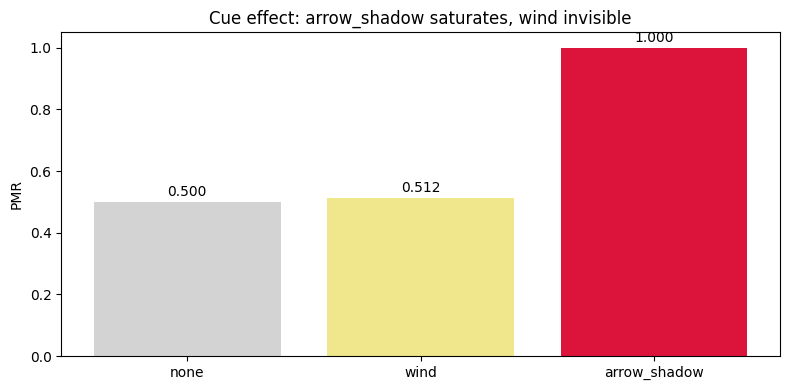

In [14]:
cue_df = sums["by_cue_level"]
cue_order = ["none", "wind", "arrow_shadow"]
cue_df = cue_df.set_index("cue_level").loc[cue_order].reset_index()
display(cue_df)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(cue_df["cue_level"], cue_df["pmr"], color=["lightgray", "khaki", "crimson"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("PMR")
ax.set_title("Cue effect: arrow_shadow saturates, wind invisible")
for b, v in zip(bars, cue_df["pmr"]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()


### PMR by prompt_variant

Open-ended *never* rejects as abstract (0.00); forced-choice rejects 45% —
the language prior from the 'ball' label fully overrides the visual signal
in open mode. Read the behavioural S-curve off the forced-choice subset.

,prompt_variant,n,pmr,hold_still,abstract_reject,gar
0,forced_choice,240,0.541667,0.387500,0.45,0.650000
1,open,240,0.800000,0.220833,0.00,0.916667


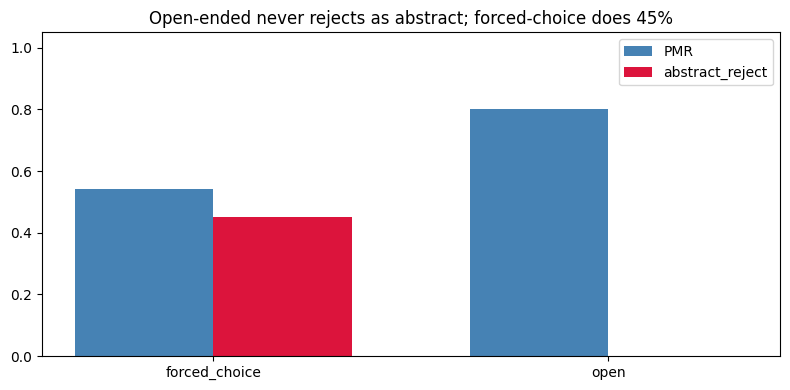

In [15]:
import numpy as np

var_df = sums["by_prompt_variant"]
display(var_df)

x = np.arange(len(var_df))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, var_df["pmr"],             w, label="PMR",             color="steelblue")
ax.bar(x + w/2, var_df["abstract_reject"], w, label="abstract_reject", color="crimson")
ax.set_xticks(x); ax.set_xticklabels(var_df["prompt_variant"])
ax.set_ylim(0, 1.05)
ax.set_title("Open-ended never rejects as abstract; forced-choice does 45%")
ax.legend()
plt.tight_layout()
plt.show()


### 2D view: object_level × cue_level

A compact read of the factorial interaction. The gradient goes from
mostly-geometric (top-left: line + none) to fully-physical (bottom-right
column: arrow_shadow) across all object levels.

cue_level,none,wind,arrow_shadow
object_level,,,
line,0.25,0.475,1.0
filled,0.50,0.475,1.0
shaded,0.50,0.425,1.0
textured,0.75,0.675,1.0


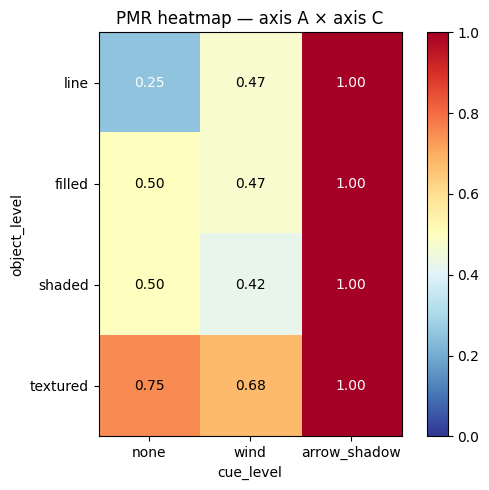

In [16]:
heat = (pilot_df.groupby(["object_level", "cue_level"])["pmr"].mean()
        .unstack()
        .reindex(index=["line", "filled", "shaded", "textured"],
                 columns=["none", "wind", "arrow_shadow"]))
display(heat.round(3))

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(heat.values, vmin=0, vmax=1, cmap="RdYlBu_r")
ax.set_xticks(range(len(heat.columns))); ax.set_xticklabels(heat.columns)
ax.set_yticks(range(len(heat.index)));   ax.set_yticklabels(heat.index)
ax.set_xlabel("cue_level"); ax.set_ylabel("object_level")
ax.set_title("PMR heatmap — axis A × axis C")
for i in range(len(heat.index)):
    for j in range(len(heat.columns)):
        ax.text(j, i, f"{heat.values[i, j]:.2f}",
                ha="center", va="center",
                color="black" if 0.3 < heat.values[i, j] < 0.8 else "white")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


---
## Conclusions

1. **Background (ground line) is the dominant single cue.** +36 pp PMR
   from blank → ground. Consistent with cognitive-science predictions
   about support planes anchoring physical-object interpretation.
2. **Abstraction axis produces a weak, partial S-curve.** Endpoints
   behave as predicted (line 0.58 → textured 0.81); middle levels tied.
3. **Trajectory arrow saturates PMR at 1.00** — the next round should
   split it into shadow-only and arrow-only sub-cues so the
   ground-attachment (Kersten/Mamassian) prediction can be measured
   independently.
4. **Wind streaks are invisible to Qwen2.5-VL-7B** — re-render as
   motion blur or dust for MVP-full.
5. **Open-ended PMR is dominated by the "ball" label**; forced-choice
   rejects as abstract ~45 % of the time. The cleaner behavioural
   S-curve should be read off forced-choice.

### What comes next

See `docs/04_next_steps.md` for concrete entry points. In order:

- MVP-full run with:
  - `temperature=0.7` + more seeds so RC is informative
  - axis D labels = `("circle", "ball", "planet")` for H2 language-prior test
  - `capture_lm_layers=(5, 10, 15, 20, 25)` so Sub-task 3 has activations
- Sub-task 2 — linear probes on captured vision-encoder activations
- Sub-task 3 — logit lens at visual-token positions per Neo et al. 2024
- Sub-task 4 — activation patching / VTI steering on Semantic Image Pairs
- Sub-task 5 — cross-model sweep (LLaVA-1.5, InternVL2, Qwen2-VL)
